In [2]:
import requests
from bs4 import BeautifulSoup
import time
from IPython.display import clear_output   # print 출력값 청소하는 기능

user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36"
headers = {"User-Agent": user_agent}

BASE_URL = "https://novel.naver.com"          # 메인 도메인 주소
novel_id = "1232607"                          # 소설 고유번호

max_page = 49                                 # 해당 소설 페이지 수
all_records = []                              # 최종 결과본 담을 리스트

print(" 크롤링을 시작합니다...")

for page in range(1, max_page + 1):           # 다른 소설 적용할 때 수정 덜 하기 위함
    page_url = f"https://novel.naver.com/best/list?novelId={novel_id}&page={page}"  # page 조사 url 설정
    page_response = requests.get(page_url, headers=headers, timeout=5)              # url의 데이터 받아오기
    page_soup = BeautifulSoup(page_response.text, "html.parser")                    # 받아온 데이터 보관

    
                     # 회차 1개의 박스 조회(분류 작업할 준비)
    episode_container = page_soup.select("li.volumeComment")                        #li 태그의 volumeComment 클래스    
     
    if not episode_container:                                                       # 만약에 박스가 존재하지 않은 경우
        clear_output()                                                  
        print(f"\n {page-1}페이지에서 더 이상 회차가 없어 종료합니다.")                 # 회차 없으니 종료
        break
        
          # \r과 end=""를 쓰면 밑으로 누적되지 않고 한 줄만 출력
    print(f"\r {page}/{max_page}페이지 수집 중...", end="")     

    

    for episode in episode_container:                                              # 해당 회차박스 내에서
        title = episode.select_one("div.list_info p.subj").get_text(strip=True)       # 제목 저장
        link = BASE_URL + episode.select_one("a.list_item")["href"]                   # 링크 저장
        
     # div 태그의 list_info 클래스에서  span 태그의 score_area클래스 하나 가져오기
        star_tag = episode.select_one("div.list_info span.score_area")          
        
    # 태그에서 글자만 뽑아오는데 별점은 공백으로 바꿔 / 단, 있으면 가져오고, 없으면 0.0 이라고 해
        star = star_tag.get_text(strip=True).replace("별점", "") if star_tag else "0.0" # 평점 저장
        
        all_records.append([title, link, star]) # 추출한 걸 all_records에 넣어
    
    time.sleep(0.5)  # 딜레이가 있을테니까. 0.5초마다 작업해
    
clear_output()
print(f"{len(all_records)}개의 데이터가 수집되었습니다.") # 크롤링 반복문이 모두 끝난 직후 총 개수 출력

482개의 데이터가 수집되었습니다.


In [4]:
# 표로 만들기
import pandas as pd
df_episodes = pd.DataFrame(all_records, columns=["제목", "링크", "평점"])
print(df_episodes.head())

               제목                                                 링크   평점
0    UP482화 전투의 끝  https://novel.naver.com/best/detail?novelId=12...  0.0
1   UP481화 마지막 저항  https://novel.naver.com/best/detail?novelId=12...  0.0
2  UP480화 신성한 황금빛  https://novel.naver.com/best/detail?novelId=12...  0.0
3    UP479화 빛의 사명  https://novel.naver.com/best/detail?novelId=12...  0.0
4   UP478화 전설의 진실  https://novel.naver.com/best/detail?novelId=12...  0.0


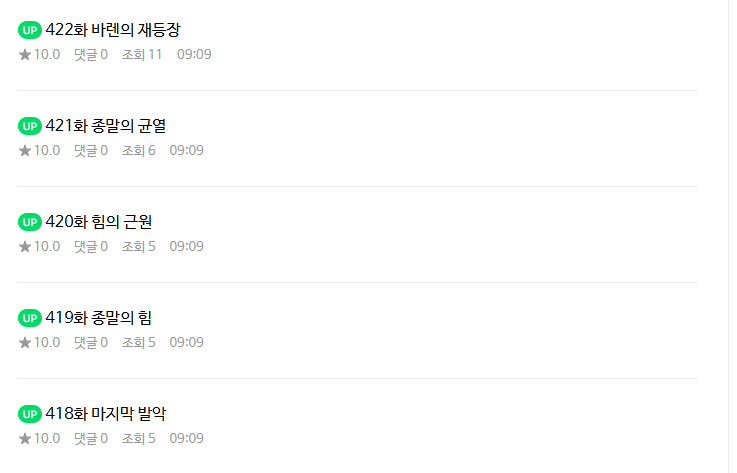

In [5]:
# 파일로 저장

df_episodes.to_csv("naver_novel.csv", index=False, encoding="utf-8-sig")
print("저장완료")

저장완료
